In [5]:
#importing
import csv
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import keras
import pandas as pd
import xgboost as xgb
import os
from scipy.stats import norm

from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score

In [6]:
XGBoost_distances_all_data = []

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15604
X shape: (15604, 16)
y shape: (15604, 2)
X coordinate range: -29.9999 to 29.9952
Y coordinate range: -29.9876 to 29.9973
Average XGBoost Delta X (mm): -0.003008932008745472
Median XGBoost Delta X (mm): -0.001057723493576225
Average XGBoost Delta Y (mm): -0.0002855660105764118
Median XGBoost Delta Y (mm): -0.002822159433364178


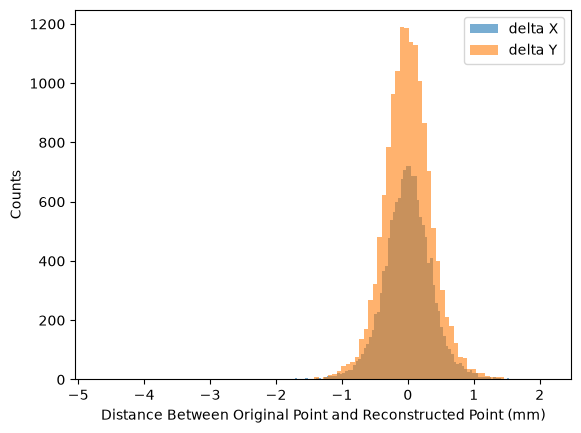

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15523
X shape: (15523, 16)
y shape: (15523, 2)
X coordinate range: -29.9979 to 29.9977
Y coordinate range: -29.9955 to 29.9965
Average XGBoost Delta X (mm): -0.0011099725360244298
Median XGBoost Delta X (mm): -0.0019307279968259622
Average XGBoost Delta Y (mm): 0.00048392018756779386
Median XGBoost Delta Y (mm): -0.0003518737792962386


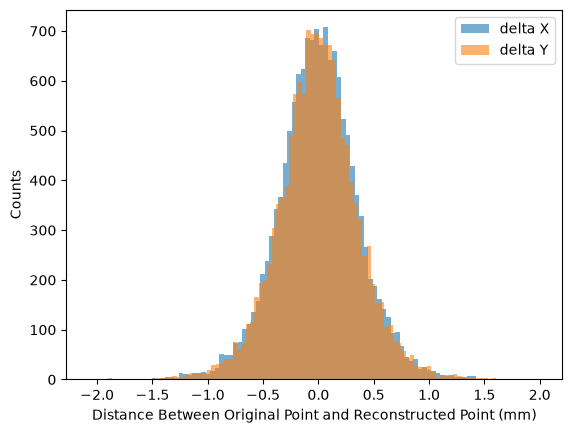

Original number of events: 100000
Original X shape: (100000, 16)
Original y shape: (100000, 2)

After 5 mm cut:
Number of events: 77868
X shape: (77868, 16)
y shape: (77868, 2)
X coordinate range: -29.9996 to 29.9994
Y coordinate range: -29.9984 to 29.998
Average XGBoost Delta X (mm): -0.0006783872897619894
Median XGBoost Delta X (mm): 0.0007287258911137656
Average XGBoost Delta Y (mm): 0.0002714056990916665
Median XGBoost Delta Y (mm): 0.0009954137802885288


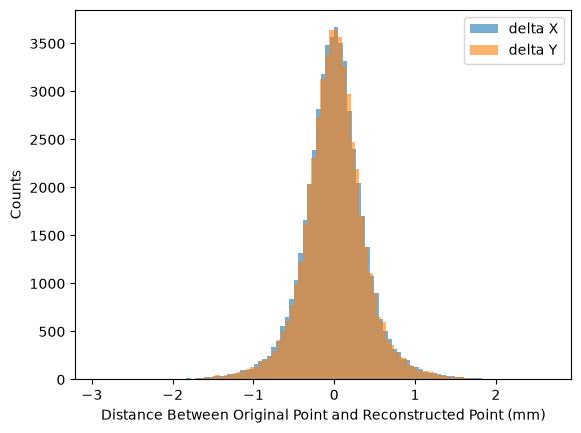

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15583
X shape: (15583, 16)
y shape: (15583, 2)
X coordinate range: -29.996 to 29.9907
Y coordinate range: -29.999 to 29.9982
Average XGBoost Delta X (mm): -0.004421705897165104
Median XGBoost Delta X (mm): 0.000401319885253321
Average XGBoost Delta Y (mm): -0.001649408048199739
Median XGBoost Delta Y (mm): -0.0004410896301266544


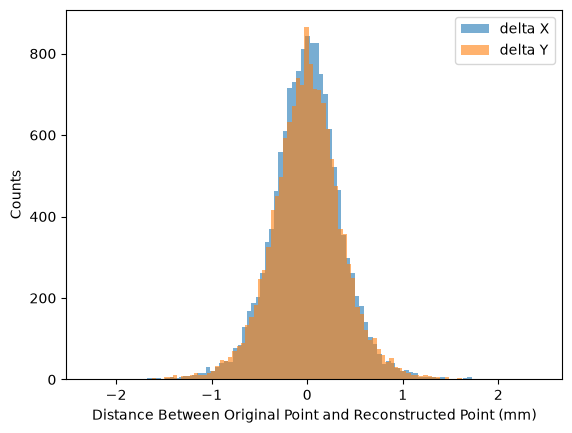

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15589
X shape: (15589, 16)
y shape: (15589, 2)
X coordinate range: -29.9975 to 29.9936
Y coordinate range: -29.9925 to 29.9962
Average XGBoost Delta X (mm): -0.0010131308885564104
Median XGBoost Delta X (mm): 0.0037922561645494512
Average XGBoost Delta Y (mm): -0.001087720923586717
Median XGBoost Delta Y (mm): -0.0017137860107421798


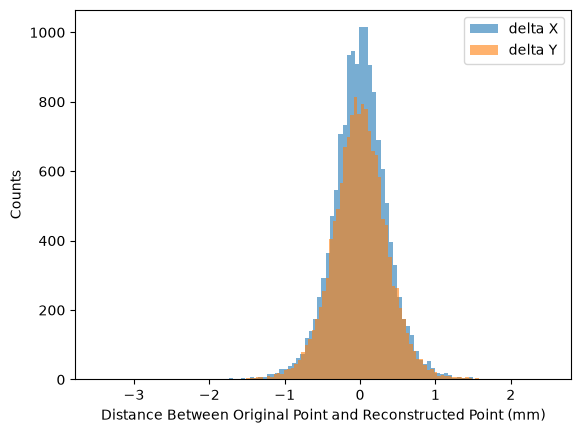

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15585
X shape: (15585, 16)
y shape: (15585, 2)
X coordinate range: -29.998 to 29.9903
Y coordinate range: -29.9953 to 29.9944
Average XGBoost Delta X (mm): 0.0012116204528814032
Median XGBoost Delta X (mm): -0.0005613887023925338
Average XGBoost Delta Y (mm): -0.0017584860144889845
Median XGBoost Delta Y (mm): -0.002588778686524051


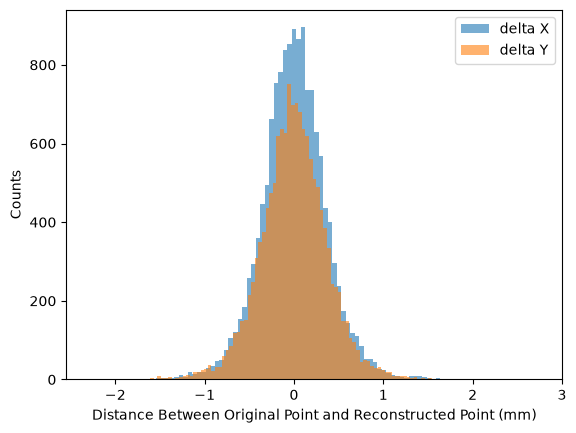

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15576
X shape: (15576, 16)
y shape: (15576, 2)
X coordinate range: -29.9987 to 29.9866
Y coordinate range: -29.9986 to 29.9998
Average XGBoost Delta X (mm): -1.7510517319087975e-05
Median XGBoost Delta X (mm): 0.0004840939331055352
Average XGBoost Delta Y (mm): 0.0003530451603367123
Median XGBoost Delta Y (mm): -0.0018503181457514804


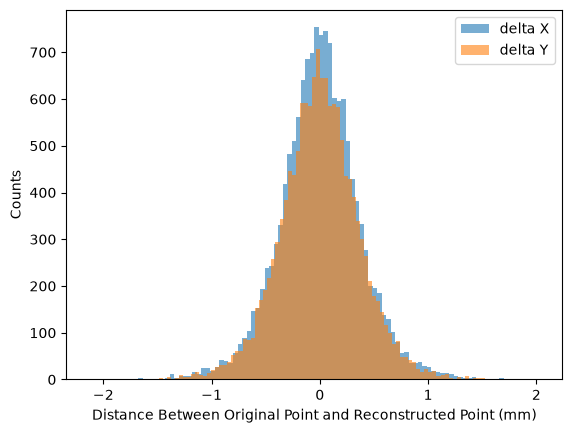

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15526
X shape: (15526, 16)
y shape: (15526, 2)
X coordinate range: -29.9978 to 29.9991
Y coordinate range: -29.9989 to 29.9993
Average XGBoost Delta X (mm): 0.0031056537527010897
Median XGBoost Delta X (mm): 0.0018009151458738162
Average XGBoost Delta Y (mm): 0.001938018837064444
Median XGBoost Delta Y (mm): 0.0012893815517427392


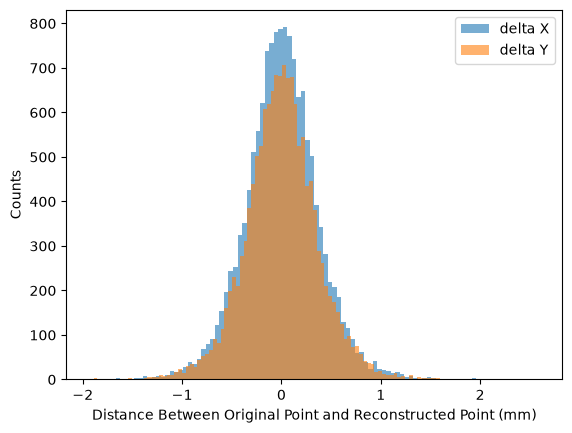

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15462
X shape: (15462, 16)
y shape: (15462, 2)
X coordinate range: -29.9998 to 29.9987
Y coordinate range: -29.9998 to 29.99
Average XGBoost Delta X (mm): 0.0014509612674244426
Median XGBoost Delta X (mm): 0.00039033813476691947
Average XGBoost Delta Y (mm): 4.4514746696247085e-05
Median XGBoost Delta Y (mm): 0.0013291383361824505


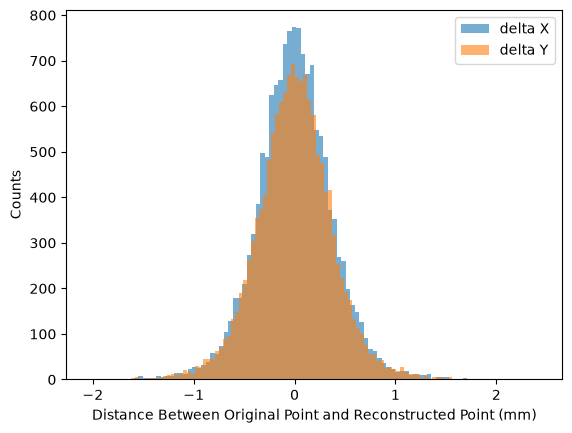

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15537
X shape: (15537, 16)
y shape: (15537, 2)
X coordinate range: -29.9938 to 29.9919
Y coordinate range: -29.9953 to 29.9924
Average XGBoost Delta X (mm): 0.0022457670315816315
Median XGBoost Delta X (mm): -4.047500610333604e-05
Average XGBoost Delta Y (mm): 0.0002026925120506634
Median XGBoost Delta Y (mm): -5.104370117336998e-05


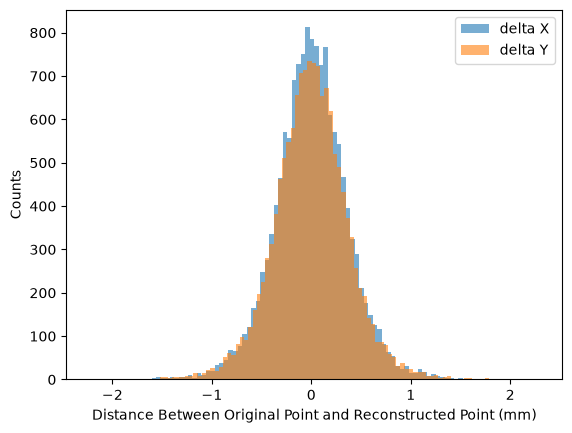

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15558
X shape: (15558, 16)
y shape: (15558, 2)
X coordinate range: -29.9973 to 29.9958
Y coordinate range: -29.9919 to 29.999
Average XGBoost Delta X (mm): 0.00048334562011526186
Median XGBoost Delta X (mm): -0.0002912384796141254
Average XGBoost Delta Y (mm): 0.00013624405166757104
Median XGBoost Delta Y (mm): -0.000500320077395474


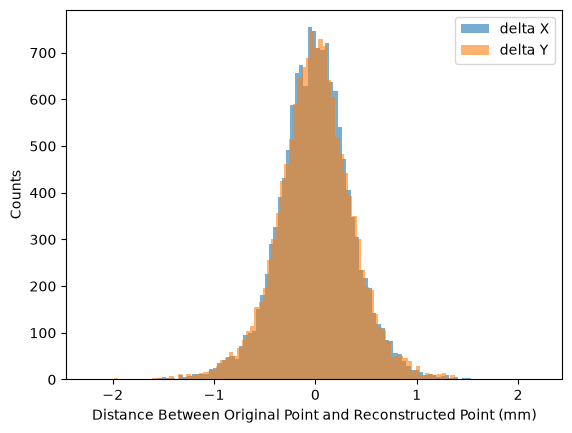

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15569
X shape: (15569, 16)
y shape: (15569, 2)
X coordinate range: -29.9997 to 29.9996
Y coordinate range: -29.9936 to 29.9994
Average XGBoost Delta X (mm): 0.0010537784849668015
Median XGBoost Delta X (mm): -0.00014672317504852567
Average XGBoost Delta Y (mm): 0.0011473113957391314
Median XGBoost Delta Y (mm): 0.0019336131286616688


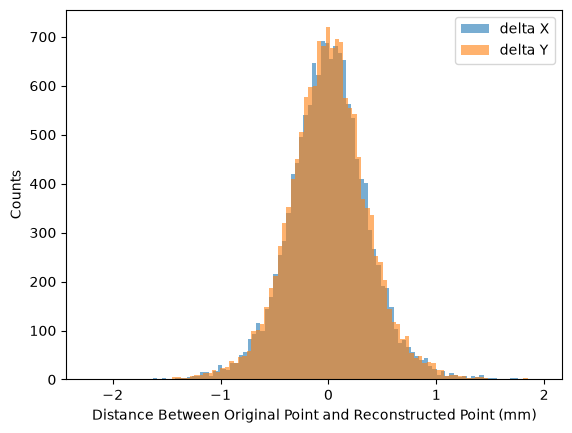

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15662
X shape: (15662, 16)
y shape: (15662, 2)
X coordinate range: -29.9938 to 29.9952
Y coordinate range: -29.9998 to 29.9959
Average XGBoost Delta X (mm): -0.002371695476601776
Median XGBoost Delta X (mm): -0.0009060127258301485
Average XGBoost Delta Y (mm): -0.0009842579110215023
Median XGBoost Delta Y (mm): 0.0010922171020506877


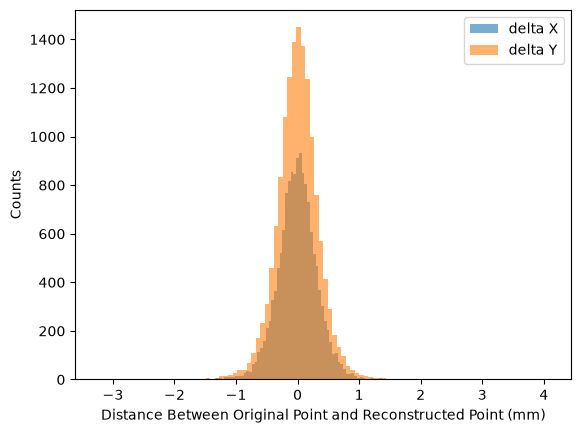

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15533
X shape: (15533, 16)
y shape: (15533, 2)
X coordinate range: -29.9981 to 29.9913
Y coordinate range: -29.9984 to 29.9972
Average XGBoost Delta X (mm): 0.0005028936723688495
Median XGBoost Delta X (mm): 0.0017219104766851923
Average XGBoost Delta Y (mm): 0.0004726016541322227
Median XGBoost Delta Y (mm): -0.0006931321334842106


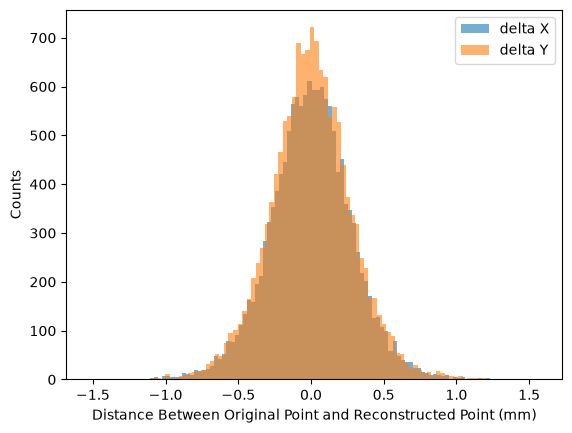

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15616
X shape: (15616, 16)
y shape: (15616, 2)
X coordinate range: -29.9998 to 29.9999
Y coordinate range: -29.9997 to 29.998
Average XGBoost Delta X (mm): -0.00312711216761657
Median XGBoost Delta X (mm): -0.0020830357360843293
Average XGBoost Delta Y (mm): -0.00024361083579481618
Median XGBoost Delta Y (mm): -0.0019419538879393537


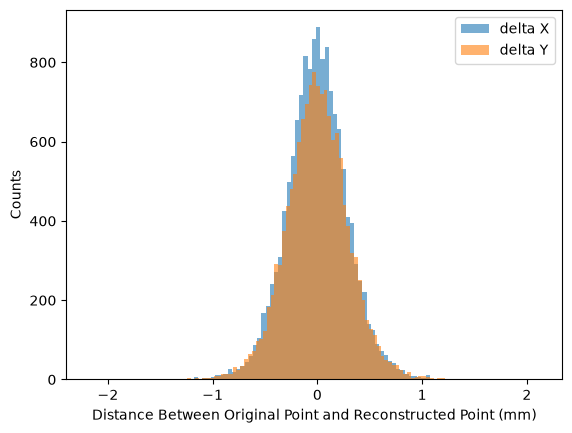

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15621
X shape: (15621, 16)
y shape: (15621, 2)
X coordinate range: -29.9923 to 29.9991
Y coordinate range: -29.9991 to 29.9965
Average XGBoost Delta X (mm): -0.0003491291925521935
Median XGBoost Delta X (mm): -0.0035106628417970933
Average XGBoost Delta Y (mm): -0.0006682265653951496
Median XGBoost Delta Y (mm): -0.000894346618652276


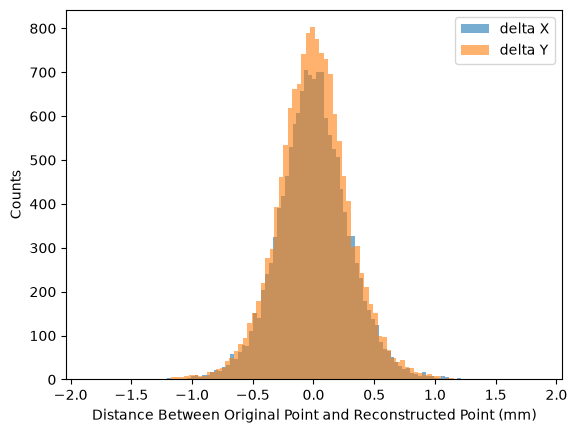

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15567
X shape: (15567, 16)
y shape: (15567, 2)
X coordinate range: -29.9998 to 29.989
Y coordinate range: -29.9984 to 29.9995
Average XGBoost Delta X (mm): -0.0009424414738166485
Median XGBoost Delta X (mm): -0.0014622833251955627
Average XGBoost Delta Y (mm): -2.3189535816166566e-05
Median XGBoost Delta Y (mm): -0.001298172531127578


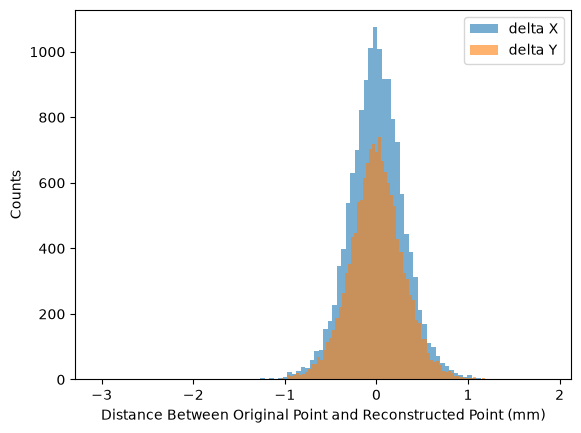

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15585
X shape: (15585, 16)
y shape: (15585, 2)
X coordinate range: -29.9949 to 29.9937
Y coordinate range: -29.999 to 29.9874
Average XGBoost Delta X (mm): -0.0006557838809679871
Median XGBoost Delta X (mm): -0.0005350662231442989
Average XGBoost Delta Y (mm): -0.0004888750343457056
Median XGBoost Delta Y (mm): 0.0031145858764652715


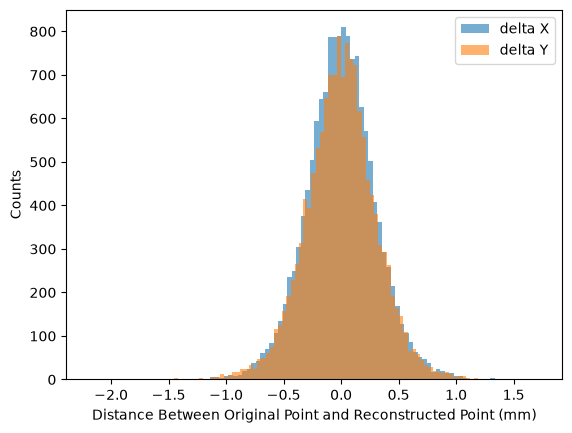

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15633
X shape: (15633, 16)
y shape: (15633, 2)
X coordinate range: -29.9988 to 29.9966
Y coordinate range: -29.997 to 29.9963
Average XGBoost Delta X (mm): -0.001292787252551278
Median XGBoost Delta X (mm): -0.0022277767181401874
Average XGBoost Delta Y (mm): -0.0007657057900241815
Median XGBoost Delta Y (mm): 0.0007256536102288071


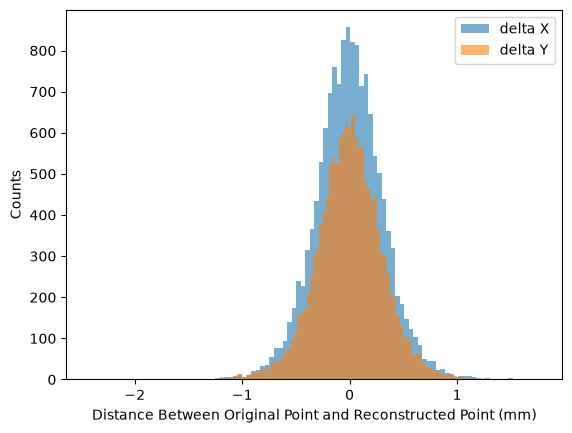

Original number of events: 20000
Original X shape: (20000, 16)
Original y shape: (20000, 2)

After 5 mm cut:
Number of events: 15513
X shape: (15513, 16)
y shape: (15513, 2)
X coordinate range: -29.9993 to 29.9949
Y coordinate range: -29.9942 to 29.9982
Average XGBoost Delta X (mm): -0.0009395697165656438
Median XGBoost Delta X (mm): 0.00048116146087665663
Average XGBoost Delta Y (mm): -7.046176525611241e-05
Median XGBoost Delta Y (mm): 0.0031781593112948344


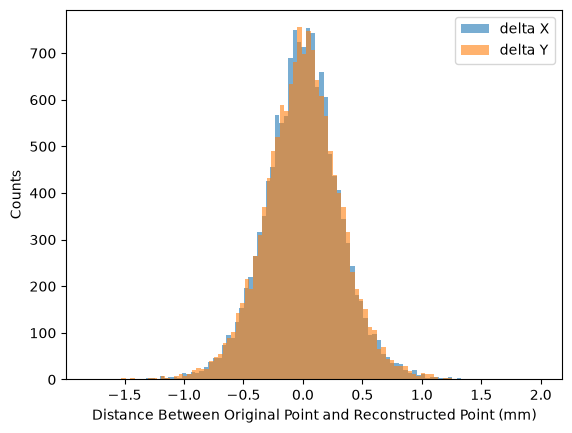

In [7]:
numbers = [3.05, 4.05, 5.05, 6.05, 7.05,8.05, 9.05, 10.05, 11.05, 12.05,13.05, 14.05, 15.05, 16.05, 17.05, 18.05, 19.05, 20.05, 25.05, 40.05]

# new region: x = -30 mm to +30 mm; y = -30 mm to +30 mm
region_size = 30  # half-width in mm
grid_half_size = round(region_size * 5)
grid_size = 2 * grid_half_size + 1

for q in numbers:

    file_path = os.path.join('/Users/judyz/Desktop/PET-4x4/build',f'{q}mm',f'{q}mm.csv')
    csvreader = csv.reader(open(file_path))

    original_X = []
    original_y = []

    line_count = 0
    for row in csvreader:
        if line_count >= 1:

            original_X.append([int(i) for i in row[1:17]])
            original_y.append([float(row[17]),float(row[18])])
        line_count += 1

    X = np.array(original_X)
    y = np.array(original_y)

    print("Original number of events:", len(X))
    print("Original X shape:", X.shape)
    print("Original y shape:", y.shape)

    mask = (
        (y[:, 0] >= -region_size) &
        (y[:, 0] <= region_size) &
        (y[:, 1] >= -region_size) &
        (y[:, 1] <= region_size)
    )

    X = X[mask]
    y = y[mask]

    print("\nAfter 5 mm cut:")
    print("Number of events:", len(X))
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    print("X coordinate range:",np.min(y[:, 0]),"to",np.max(y[:, 0]))
    print("Y coordinate range:",np.min(y[:, 1]),"to",np.max(y[:, 1]))

    #XGBoost
    # 60 mm x 60 mm region; 301 x 301 grid

    XGBoost_distances = np.zeros(
        (grid_size, grid_size, 2)
    )

    scaler = StandardScaler()

    for k in range(10):

        X_XGBoost = scaler.fit_transform(X)
        X_train, X_val, y_train, y_val = train_test_split(X_XGBoost, y, test_size=0.3)
            
        model = xgb.XGBRegressor()
        model.fit(X_train,y_train)

        yhat = model.predict(X_XGBoost)
        for i in range(len(X)):

            x_index = grid_half_size + round(y[i][0] * 5)
            y_index = grid_half_size - round(y[i][1] * 5)

            if (0 <= x_index < grid_size and 0 <= y_index < grid_size):
                XGBoost_distances[x_index,y_index,0] = k/(k+1)*XGBoost_distances[x_index,y_index,0] + 1/(k+1)*(yhat[i][0] - y[i][0])
                XGBoost_distances[x_index,y_index,1] = k/(k+1)*XGBoost_distances[x_index,y_index,1] + 1/(k+1)*(yhat[i][1] - y[i][1])
    delta_x = XGBoost_distances[:, :, 0]
    delta_y = XGBoost_distances[:, :, 1]

    delta_x = delta_x[delta_x != 0]
    delta_y = delta_y[delta_y != 0]

    print("Average XGBoost Delta X (mm):",np.mean(delta_x))
    print("Median XGBoost Delta X (mm):",np.median(delta_x))
    print("Average XGBoost Delta Y (mm):",np.mean(delta_y))
    print("Median XGBoost Delta Y (mm):",np.median(delta_y))

    plt.hist(delta_x,bins=100,alpha=0.6,label='delta X')
    plt.hist(delta_y,bins=100,alpha=0.6,label='delta Y')
    plt.xlabel('Distance Between Original Point and Reconstructed Point (mm)')
    plt.ylabel('Counts')
    plt.legend(loc='upper right')
    plt.show()

    XGBoost_distances_all_data.append(XGBoost_distances)

20


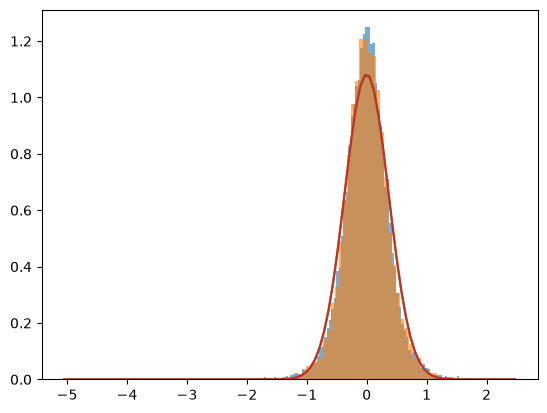

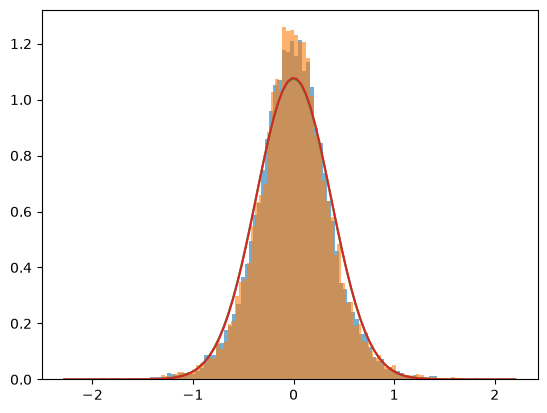

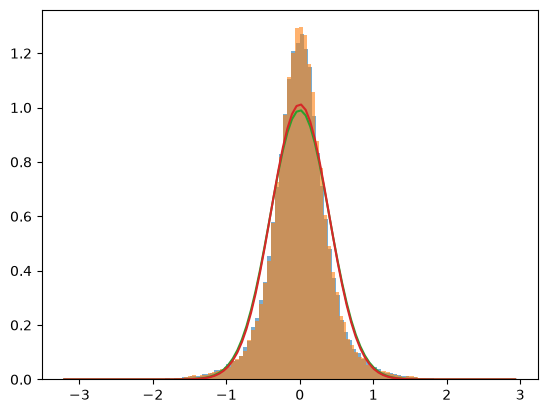

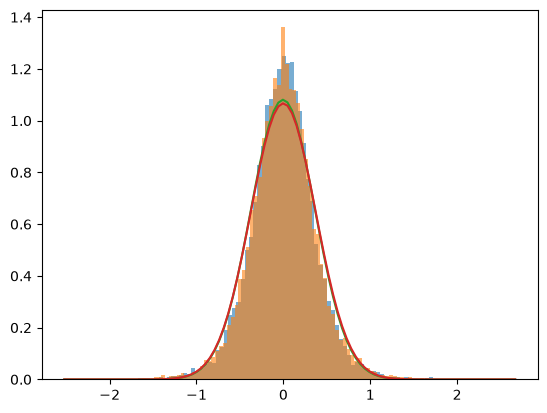

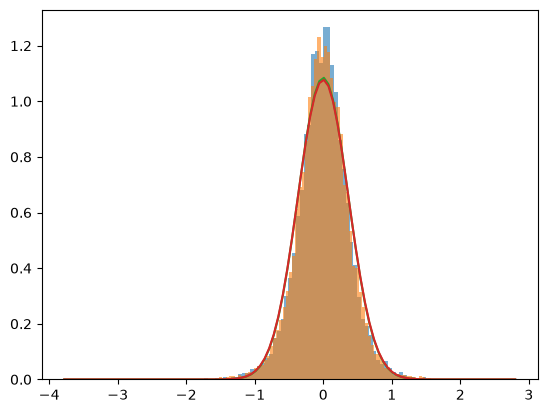

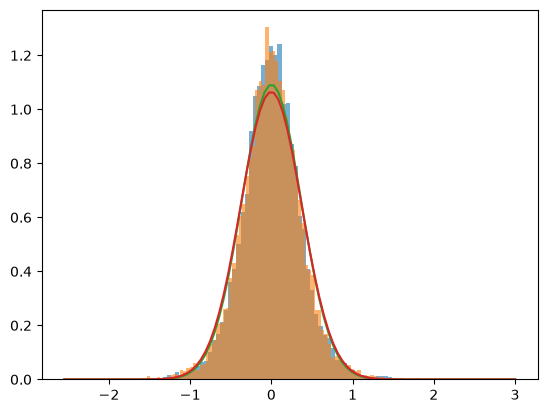

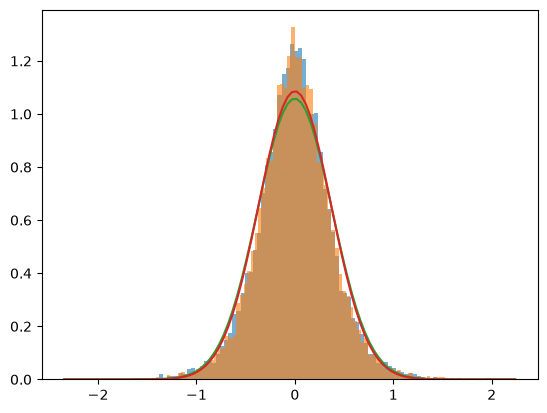

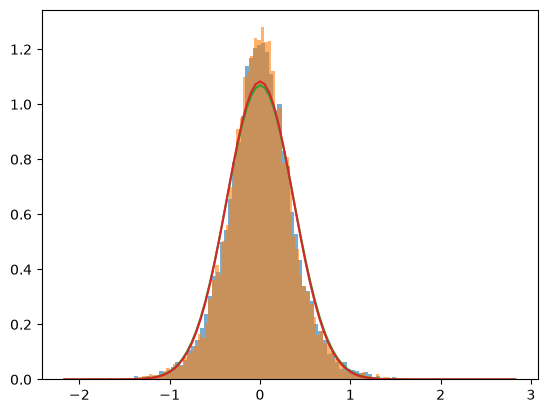

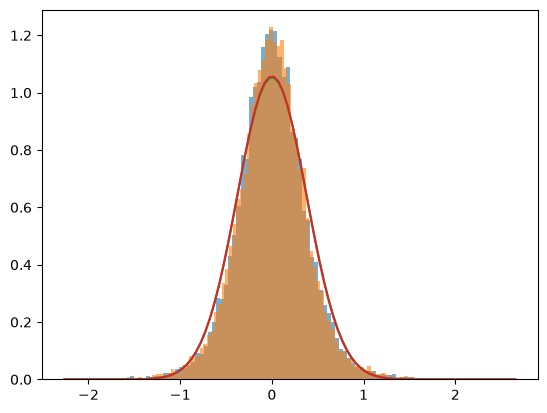

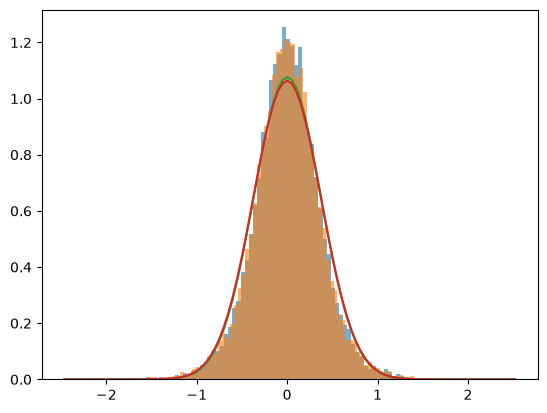

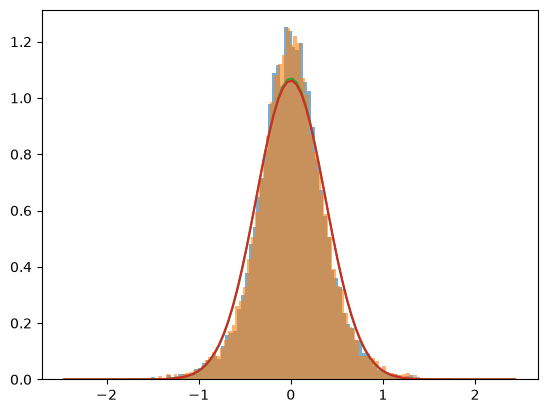

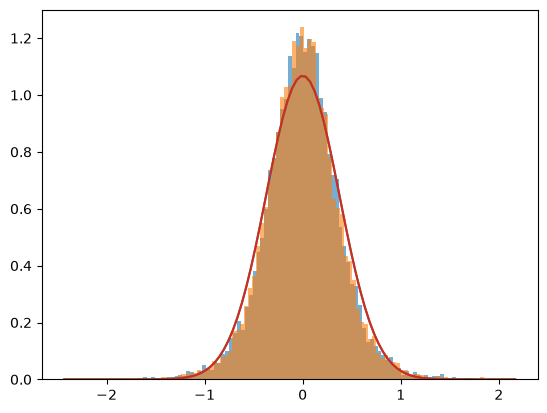

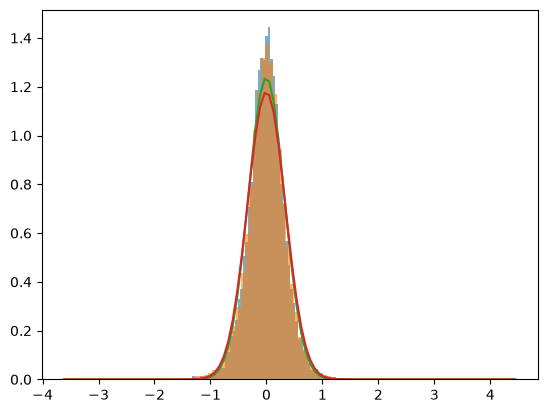

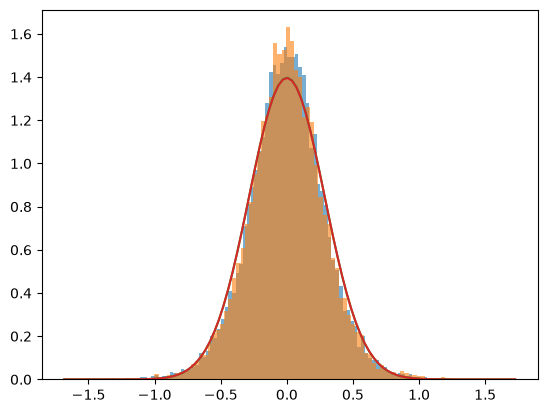

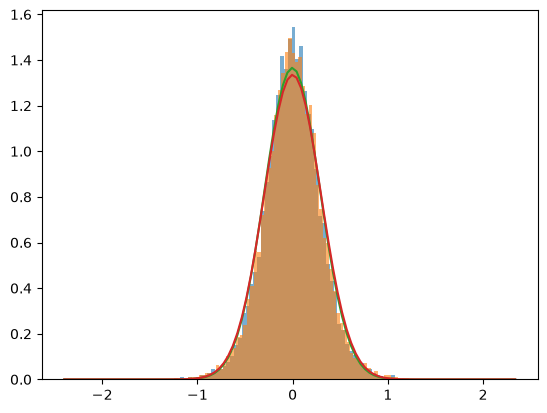

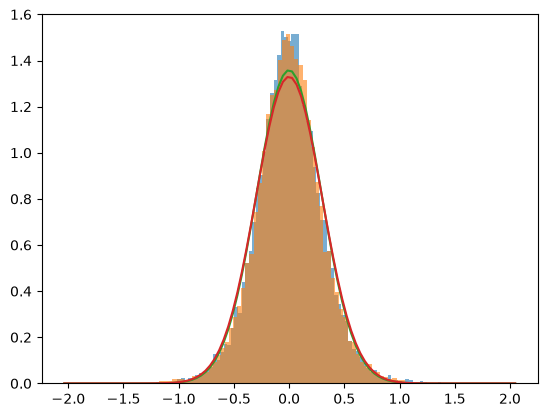

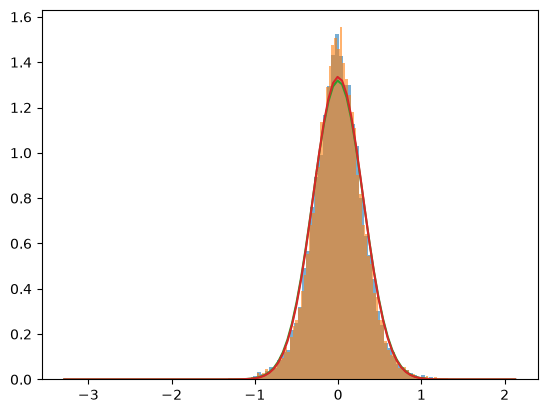

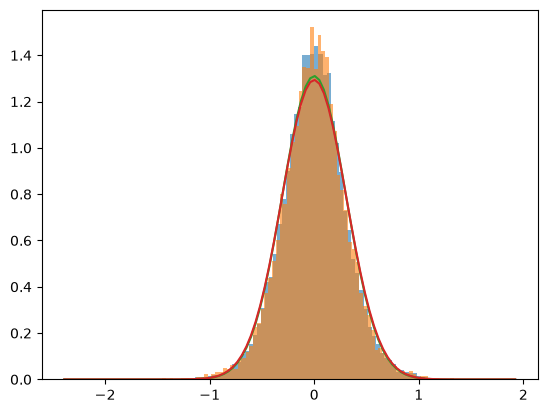

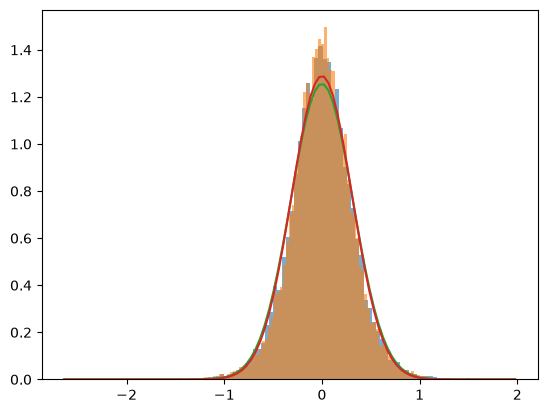

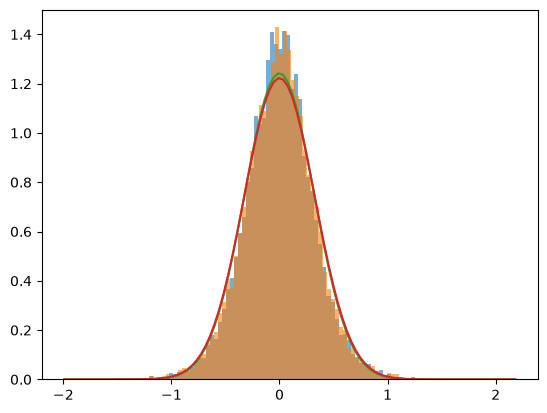

In [8]:
standard_deviations = []
means = []
print(len(XGBoost_distances_all_data))


for element in XGBoost_distances_all_data:

    delta_x = element[:, :, 0]
    delta_x = delta_x[delta_x != 0]

    delta_y = element[:, :, 1]
    delta_y = delta_y[delta_y != 0]

    meanx, stdx = norm.fit(delta_x)
    meany, stdy = norm.fit(delta_y)

    standard_deviations.append([stdx, stdy])
    means.append([meanx, meany])

    plt.hist(delta_x,bins=100,alpha=0.6,label='delta X',density=True)
    plt.hist(delta_y,bins=100,alpha=0.6,label='delta Y',density=True)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)

    xy = norm.pdf(x, meanx, stdx)
    yy = norm.pdf(x, meany, stdy)

    plt.plot(x, xy)
    plt.plot(x, yy)

    plt.show()

In [9]:
# Standard deviations
std_x = np.std(delta_x)
std_y = np.std(delta_y)

print("Standard Deviation X (mm):", std_x)
print("Standard Deviation Y (mm):", std_y)

Standard Deviation X (mm): 0.32105240690603304
Standard Deviation Y (mm): 0.32622940614800794


In [10]:
XGBoost_distances_all_data_np = np.array(XGBoost_distances_all_data)
print(XGBoost_distances_all_data_np.shape)
np.savetxt('XGBoost_distances_delta_cut.csv', XGBoost_distances_all_data_np.reshape(XGBoost_distances_all_data_np.shape[0], -1))

(20, 301, 301, 2)
